# Round-Trip Correctness (RTC) Evaluation

Pull predictions from existing MLflow runs (same runs as `llm_judge_prompts.ipynb`),
and score them with **round-trip correctness**, following the methodology from
Allamanis et al., ["Unsupervised Evaluation of Code LLMs with Round-Trip
Correctness"](https://github.com/google-deepmind/icml2024-roundtrip-correctness)
(ICML 2024). No LLM judge anywhere in this notebook -- the consistency check
below is a mechanical text metric, not a model call.

## Methodology

RTC evaluates a *forward* transform (code -> description) without human
annotations by composing it with a *backward* transform (description -> code)
and checking whether the round trip is consistent:

1. **Forward**: the summarization system under test produces `prediction`
   (a description) from `code`. Already available from the MLflow runs.
2. **Backward**: a separate LLM is given the file the function came from, with
   the function replaced by a `TODO` comment holding the forward `prediction`,
   and re-synthesizes the function (`synthesis_rtc/task.py`'s
   `code_with_todo_at_hole`, fill-in-the-middle).
3. **Consistency check**: how similar is the round-tripped code to the
   original `code`, measured as **BLEU-4** between the two code strings. This
   is a continuous relaxation of the reference repo's own text-comparison
   metric -- `editing_rtc/eval_codereviewer.py`'s
   `{"exact_match": float(prediction == original)}` -- swapped from exact
   equality to BLEU because our backward task (full function-body synthesis
   from a description) makes exact string equality against the original
   source near-impossible even for a perfect reconstruction (different
   variable names, formatting, control-flow shape). The repo's other
   consistency metric, pytest pass/fail in Docker
   (`synthesis_rtc/eval_for_program.py`), needs a buildable checkout with
   tests per sample, which this multi-repo, multi-language dataset can't
   guarantee -- see the note below.

A system whose descriptions round-trip to more similar code is producing
summaries that better capture the code's actual behavior -- this is a
self-consistency signal, not a comparison to a human reference, so it's
complementary to the reference-based BLEU used elsewhere in this project
(computed here too, at the end, for comparison).

### Note on what this metric can and can't tell you

BLEU-on-code is a surface-similarity proxy, not a behavioral-equivalence
check -- two functions can score low on BLEU while being behaviorally
identical (renamed variables, reordered branches, different but equivalent
library calls), or score high while being subtly wrong (one flipped
comparison). Treat `rtc_bleu` as a graded signal for ranking systems against
each other, not as ground truth for any individual sample -- the real
`SynthesisRTC` (pytest pass/fail) is the paper's ground truth, and this
notebook doesn't have the execution harness to reproduce it.

In [1]:
# ── Config ──────────────────────────────────────────────────────────────────
REPO_ROOT = "/home/phuc/code-sum"

RUN_IDS = {
    #"few_shot_llm": "8ed48f980c5540e8b029056b268867e8",
    "few_shot_all_context": "7e938318a5974bcaaf0c424d43bae43e",
    #"few_shot_all_context_4o": "81a2b718862c4b36aefdc0ec66dae63b",
    "agentic_rag": "b06fc2a80b074b94bd4ff88337950cbb",
    "agentic_rag_llama": "30a694addc1a423db385f0869c7e172f",
    #"zero_shot": "5987585716d54933b79acdbedaaaad15",
    #"metagente": "512522dd8ba14ff4b8930906cea34a0f",
}

# Backward pass: description -> code. Deliberately a capable-but-different
# model from any system under test, so we're not just measuring "can a model
# decode its own phrasing back into code."
BACKWARD_MODEL = "openai/gpt-4o-mini"
BACKWARD_BACKEND = "openrouter"
BACKWARD_TEMPERATURE = 0.2
BACKWARD_MAX_TOKENS = 512
N_BACKWARD_SAMPLES = 1  # backward samples per forward prediction (RTC@1 by default)

# Backward-pass file context: paper splices the description into the *whole*
# source file at the target function's location (fill-in-the-middle) rather
# than prompting from a bare signature. MAX_FILE_CONTEXT_CHARS caps how much
# of the before/after file we keep, trimmed from the far ends so the text
# nearest the hole (most relevant) survives.
MAX_FILE_CONTEXT_CHARS = 4000

MAX_CONCURRENCY = 10

N_SAMPLES = 200  # sampled per run
RANDOM_SEED = 0

In [2]:
import asyncio
import json
import random
import re

import mlflow
import pandas as pd
from mlflow import MlflowClient
from tqdm.asyncio import tqdm as atqdm

from mas_code_sum.methods.llm_client import make_clients

mlflow.set_tracking_uri("http://127.0.0.1:5000")
client = MlflowClient()

/home/phuc/code-sum/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load predictions from MLflow runs

Each run logged a `predictions/*.csv` artifact with columns
`id, project, func_name, run, reference, prediction`. `id` is the row index into
`dataset/full/test.jsonl`, so we can join the original code back in.

In [3]:
import pathlib


def load_predictions(run_name: str, run_id: str) -> pd.DataFrame:
    local_dir = client.download_artifacts(run_id, "predictions")
    csvs = list(pathlib.Path(local_dir).glob("*.csv"))
    assert len(csvs) == 1, f"expected exactly one predictions csv, found {csvs}"
    df = pd.read_csv(csvs[0])
    df["system"] = run_name
    return df


pred_dfs = {name: load_predictions(name, run_id) for name, run_id in RUN_IDS.items()}
for name, df in pred_dfs.items():
    print(name, df.shape)

few_shot_all_context (200, 7)
agentic_rag (200, 7)
agentic_rag_llama (200, 7)


In [4]:
# ── Join source code + language + file location back in via dataset/full/test.jsonl ──
# repo/path/blame_sha let us load the *whole file* the function came from (needed
# for the backward pass below), the same fields few_shot_all_context/file_context
# join on.
from mas_code_sum.data import dataset_dir

_code_by_id: dict[int, dict] = {}
with open(dataset_dir() / "full" / "test.jsonl") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        sample = json.loads(line)
        _code_by_id[sample["id"]] = {
            "code": sample["code"],
            "language": sample["language"],
            "repo": sample["repo"],
            "path": sample["path"],
            "blame_sha": sample.get("blame_sha"),
        }

for name, df in pred_dfs.items():
    for field in ["code", "language", "repo", "path", "blame_sha"]:
        df[field] = df["id"].map(lambda i, field=field: _code_by_id.get(i, {}).get(field))
    missing = df["code"].isna().sum()
    if missing:
        print(f"{name}: {missing} rows with no matching code (dropping)")
    pred_dfs[name] = df.dropna(subset=["code"]).reset_index(drop=True)

In [5]:
# ── Sample rows to evaluate ──────────────────────────────────────────────────
random.seed(RANDOM_SEED)

sampled_rows = []
for name, df in pred_dfs.items():
    n = min(N_SAMPLES, len(df))
    sampled_rows.append(df.sample(n=n, random_state=RANDOM_SEED))

rtc_input_df = pd.concat(sampled_rows, ignore_index=True)
print(f"{len(rtc_input_df)} (system, sample) pairs to round-trip")
rtc_input_df.head()

600 (system, sample) pairs to round-trip


,id,project,func_name,run,reference,prediction,system,code,language,repo,path,blame_sha
0,218,apache/airflow,DagRun.get_previous_dagrun,0,The previous DagRun if there is one,Get the previous DagRun for this DagRun.,few_shot_all_context,"def get_previous_dagrun(self, session=None):\n...",python,apache/airflow,airflow/models/dagrun.py,6970b233964ee254bbb343ed8bdc906c2f7bd974
1,1820,tamboui/tamboui,Monthly.of,0,Creates a calendar for the month containing th...,"Based on the provided code and summaries, here...",few_shot_all_context,public static Monthly of(LocalDate displayDate...,java,tamboui/tamboui,tamboui-widgets/src/main/java/dev/tamboui/widg...,de998ecd7a669e15ec4e8aad34ef3e6533389b0b
2,1607,newton-physics/newton,ViewerBase._qualify,0,Prefix a backend object name with the active l...,Qualify a name with the active layer's name pr...,few_shot_all_context,"def _qualify(self, name: str | None) -> str | ...",python,newton-physics/newton,newton/_src/viewer/viewer.py,9f514571f18eb454654c241ed056f2efa39df451
3,548,orientechnologies/orientdb,ONodeManager.initCheckLeader,0,init the procedure that sends pings to other s...,Initializes the leader checker.,few_shot_all_context,private void initCheckLeader() {\n checkerT...,java,orientechnologies/orientdb,distributed-v2/src/main/java/com/orientechnolo...,6d236ebb21f9d6ea499d0a6e5ae665946819018e
4,1827,tamboui/tamboui,ApiLevelsSnippets.inlineTuiRunnerBasic,0,========== INLINE TUI RUNNER ==========,Runs the demo application.,few_shot_all_context,void inlineTuiRunnerBasic() throws Exception {...,java,tamboui/tamboui,docs/src/snippets/java/dev/tamboui/docs/snippe...,7b496fad6c005c061ac67d38f3bf89e83b6c08df


## Backward pass: description -> code

The reference implementation's `SynthesisRtcExample` splices the description
into the *whole source file*, not an isolated signature:
`code_with_todo_at_hole` returns
`code_before_hole + "# TODO(LLM): {description}" + code_after_hole` -- i.e. real
fill-in-the-middle, with the rest of the file (imports, sibling functions,
enclosing class) as context. Both the forward and backward passes in the
paper see the whole file; only the target region changes (marked vs. replaced
by a TODO).

We reproduce that here: load the full source file the sample came from (via
the same `repo`/`path`/`blame_sha` fields `file_context.py` uses), find where
`code` sits inside it, and splice in `# TODO(LLM): {description}` (or the
language's comment syntax) in its place. This also happens to fix the same
blind spot `llm_judge_prompts.ipynb` calls out for `few_shot_all_context`:
that system's summaries can reference things outside the isolated function
(enclosing class, siblings, imports), and a backward model that only sees a
bare signature would be unfairly penalized for context it was never given.

Falls back to a signature-only prompt (the notebook's first cut) when the
file can't be loaded or `code` can't be located inside it verbatim --
tracked below so we know how often that happens.

In [6]:
from mas_code_sum.enrichers.file_context import _load_source

_LINE_COMMENT_PREFIX = {
    "python": "#",
    "ruby": "#",
    "java": "//",
    "javascript": "//",
    "go": "//",
    "php": "//",
}


def split_file_around_code(repo: str, path: str, code: str, blame_sha: str | None) -> tuple[str, str] | None:
    # Returns (text_before, text_after) surrounding `code` in the file it came from,
    # or None if the file can't be loaded or `code` can't be found verbatim (dataset
    # extraction sometimes dedents/retokenizes code, so this is best-effort, not guaranteed).
    source = _load_source(repo, path, blame_sha)
    if source is None:
        return None
    idx = source.find(code)
    if idx == -1:
        idx = source.find(code.strip())
        if idx == -1:
            return None
    return source[:idx], source[idx + len(code):]


def truncate_file_context(before: str, after: str, max_chars: int) -> tuple[str, str]:
    # Trim before/after from the far ends (from the hole), keeping what's nearest the hole.
    half = max_chars // 2
    return before[-half:], after[:half]


def extract_signature(code: str, language: str) -> str:
    # Fallback-only: first line(s) up to the opening `:`/`{`, used when file splicing fails.
    lines = code.strip("\n").splitlines()
    if language == "python":
        for i, line in enumerate(lines):
            if line.rstrip().endswith(":"):
                return "\n".join(lines[: i + 1])
        return lines[0] if lines else ""
    for i, line in enumerate(lines):
        if "{" in line:
            return "\n".join(lines[: i + 1])
    return lines[0] if lines else ""


BACKWARD_PROMPT_FILE_TEMPLATE = '''You are reconstructing a {language} function from its description, \
in place in the file it belongs to. Below is the file with the target function \
replaced by a TODO comment describing what it should do. Write the complete \
function implementation that should replace the TODO, consistent with the \
rest of the file (naming conventions, imports, enclosing class). Do not add \
explanation -- respond with only the replacement function code.

File ({path}):
{file_with_todo}

Code:'''

BACKWARD_PROMPT_SIGNATURE_TEMPLATE = '''You are reconstructing a {language} function from its description. \
You are given the function signature and a natural-language description of what \
the function does. Write a complete, plausible implementation of the function \
body that satisfies the description. Do not add explanation -- respond with only \
the code, from the signature through the end of the function.

Signature:
{signature}

Description:
{description}

Code:'''


_CODE_FENCE_RE = re.compile(r"^```[a-zA-Z]*\n?|```$", re.MULTILINE)


def strip_code_fence(text: str) -> str:
    return _CODE_FENCE_RE.sub("", text).strip()

In [7]:
# ── Precompute file-context splices (sync, no LLM call) so we can report the fallback rate ──
def prepare_backward_prompt(row: pd.Series) -> dict:
    halves = split_file_around_code(row["repo"], row["path"], row["code"], row["blame_sha"])
    comment_prefix = _LINE_COMMENT_PREFIX.get(row["language"], "#")
    if halves is None:
        return {
            "used_file_context": False,
            "prompt": BACKWARD_PROMPT_SIGNATURE_TEMPLATE.format(
                language=row["language"],
                signature=extract_signature(row["code"], row["language"]),
                description=row["prediction"],
            ),
        }
    before, after = truncate_file_context(*halves, max_chars=MAX_FILE_CONTEXT_CHARS)
    todo_comment = f"{comment_prefix} TODO(LLM): {row['prediction']}"
    file_with_todo = f"{before}{todo_comment}\n{after}"
    return {
        "used_file_context": True,
        "prompt": BACKWARD_PROMPT_FILE_TEMPLATE.format(
            language=row["language"], path=row["path"], file_with_todo=file_with_todo
        ),
    }


_prepared = rtc_input_df.apply(prepare_backward_prompt, axis=1, result_type="expand")
rtc_input_df["used_file_context"] = _prepared["used_file_context"]
rtc_input_df["backward_prompt"] = _prepared["prompt"]

fallback_rate = (~rtc_input_df["used_file_context"]).mean()
print(f"{fallback_rate:.1%} of samples fell back to signature-only backward prompts (file not found/loadable)")

16.0% of samples fell back to signature-only backward prompts (file not found/loadable)


In [8]:
_, async_client = make_clients(BACKWARD_BACKEND)
_backward_sem = asyncio.Semaphore(MAX_CONCURRENCY)


async def backward_generate_one(row: pd.Series) -> dict:
    async with _backward_sem:
        response = await async_client.chat.completions.create(
            model=BACKWARD_MODEL,
            messages=[{"role": "user", "content": row["backward_prompt"]}],
            temperature=BACKWARD_TEMPERATURE,
            max_tokens=BACKWARD_MAX_TOKENS,
            n=N_BACKWARD_SAMPLES,
        )
    return {
        "backward_codes": [strip_code_fence(choice.message.content) for choice in response.choices],
    }


async def run_backward_pass(df: pd.DataFrame) -> pd.DataFrame:
    tasks = [backward_generate_one(row) for _, row in df.iterrows()]
    results = await atqdm.gather(*tasks, desc="backward generation")
    out = df.copy().reset_index(drop=True)
    out["backward_codes"] = [r["backward_codes"] for r in results]
    return out.explode("backward_codes", ignore_index=True).rename(columns={"backward_codes": "backward_code"})


rtc_backward_df = await run_backward_pass(rtc_input_df)
rtc_backward_df[["system", "id", "func_name", "used_file_context", "prediction", "backward_code"]].head()

backward generation: 100%|██████████| 600/600 [02:41<00:00,  3.71it/s]


,system,id,func_name,used_file_context,prediction,backward_code
0,few_shot_all_context,218,DagRun.get_previous_dagrun,True,Get the previous DagRun for this DagRun.,@provide_session\n def get_previous_dagrun(...
1,few_shot_all_context,1820,Monthly.of,True,"Based on the provided code and summaries, here...",/**\n * Creates a calendar for the month c...
2,few_shot_all_context,1607,ViewerBase._qualify,True,Qualify a name with the active layer's name pr...,"def _qualify_layer_name(self, name: str) -> st..."
3,few_shot_all_context,548,ONodeManager.initCheckLeader,False,Initializes the leader checker.,private void initCheckLeader() {\n // Initi...
4,few_shot_all_context,1827,ApiLevelsSnippets.inlineTuiRunnerBasic,False,Runs the demo application.,void inlineTuiRunnerBasic() throws Exception {...


## Consistency check: BLEU between original and round-tripped code

Same smoothed corpus-BLEU-4 formula the project logs to MLflow (inlined here,
import-free), but applied to *code* instead of natural-language summaries:
`sentence_bleu(code, backward_code)`. No model call -- purely mechanical.

In [9]:
import sys
# ── Inlined smoothed BLEU (same formula as mas_code_sum.evaluator.bleu) ─────
import math
import xml.sax.saxutils

_normalize1 = [
    (re.compile(r"<skipped>"), ""),
    (re.compile(r"-\n"), ""),
    (re.compile(r"\n"), " "),
]
_normalize2 = [
    (re.compile(r"([\{-\~\[-\` -\&\(-\+\:-\@\/])"), r" \1 "),
    (re.compile(r"([^0-9])([\.,])"), r"\1 \2 "),
    (re.compile(r"([\.,])([^0-9])"), r" \1 \2"),
    (re.compile(r"([0-9])(-)"), r"\1 \2 "),
]


def _normalize(s):
    if not isinstance(s, str):
        s = " ".join(s)
    for pattern, replace in _normalize1:
        s = pattern.sub(replace, s)
    s = xml.sax.saxutils.unescape(s, {"&quot;": '"'})
    s = " %s " % s
    s = s.lower()
    for pattern, replace in _normalize2:
        s = pattern.sub(replace, s)
    return s.split()


def _count_ngrams(words, n=4):
    counts = {}
    for k in range(1, n + 1):
        for i in range(len(words) - k + 1):
            ngram = tuple(words[i : i + k])
            counts[ngram] = counts.get(ngram, 0) + 1
    return counts


def _cook_refs(refs, n=4):
    refs = [_normalize(ref) for ref in refs]
    maxcounts = {}
    for ref in refs:
        counts = _count_ngrams(ref, n)
        for ngram, count in counts.items():
            maxcounts[ngram] = max(maxcounts.get(ngram, 0), count)
    return [len(ref) for ref in refs], maxcounts


def _cook_test(test, item, n=4):
    reflens, refmaxcounts = item
    test = _normalize(test)
    result = {"testlen": len(test), "reflen": min(reflens)}
    result["guess"] = [max(len(test) - k + 1, 0) for k in range(1, n + 1)]
    result["correct"] = [0] * n
    counts = _count_ngrams(test, n)
    for ngram, count in counts.items():
        result["correct"][len(ngram) - 1] += min(refmaxcounts.get(ngram, 0), count)
    return result


def _score_cooked(comps, n=4):
    logbleu = 0.0
    for k in range(n):
        correct = comps["correct"][k]
        guess = comps["guess"][k]
        addsmooth = 1 if k > 0 else 0
        logbleu += math.log(correct + addsmooth + sys.float_info.min) - math.log(guess + addsmooth + sys.float_info.min)
    logbleu /= float(n)
    brev_penalty = min(0, 1 - float(comps["reflen"] + 1) / (comps["testlen"] + 1))
    return math.exp(logbleu + brev_penalty)


def sentence_bleu(reference: str, candidate: str) -> float:
    # Smoothed corpus-style BLEU-4 for a single (reference, candidate) pair, 0-100 scale.
    item = _cook_refs([reference])
    comps = _cook_test(candidate, item)
    return _score_cooked(comps) * 100

In [10]:
rtc_results = rtc_backward_df.copy()
rtc_results["rtc_bleu"] = rtc_results.apply(
    lambda row: sentence_bleu(row["code"], row["backward_code"]), axis=1
)
rtc_results[["system", "id", "func_name", "rtc_bleu"]].head()

,system,id,func_name,rtc_bleu
0,few_shot_all_context,218,DagRun.get_previous_dagrun,85.853818
1,few_shot_all_context,1820,Monthly.of,36.832111
2,few_shot_all_context,1607,ViewerBase._qualify,0.640993
3,few_shot_all_context,548,ONodeManager.initCheckLeader,20.639188
4,few_shot_all_context,1827,ApiLevelsSnippets.inlineTuiRunnerBasic,16.597414


## RTC score per system

RTC score = mean `rtc_bleu` over sampled predictions. With `N_BACKWARD_SAMPLES
> 1` this collapses multiple backward samples per forward prediction into one
row first, taking the max (best-of-k round-trip similarity), mirroring how
the paper reports pass@k-style aggregates for the binary case; with the
default `N_BACKWARD_SAMPLES = 1` it's just the raw per-sample BLEU.

In [11]:
# ── Collapse backward samples (best-of-k) back to one row per (system, id) ──
per_prediction = (
    rtc_results.groupby(["system", "id", "func_name"])["rtc_bleu"]
    .max()  # best-scoring backward sample
    .reset_index()
)

rtc_score = per_prediction.groupby("system")["rtc_bleu"].agg(mean="mean", std="std", n="count")
rtc_score.sort_values("mean", ascending=False)

,mean,std,n
system,,,
agentic_rag,30.795383,23.933069,200
agentic_rag_llama,30.367156,24.777385,200
few_shot_all_context,27.728167,23.824797,200


## Paired comparison across systems

All sampled runs predicted on the same 200 test samples in the same order,
and `rtc_input_df` sampled every system with the same `random_state`, so the
sampled `id`s line up 1:1 across systems -- this supports a paired per-sample
comparison (not just comparing independent means) for *any* pair of systems,
via one wide `id x system` pivot of `rtc_bleu`.

In [12]:
# ── Wide pivot: one row per sampled id, one column per system ───────────────
paired = per_prediction.pivot_table(index="id", columns="system", values="rtc_bleu")
paired.head()

system,agentic_rag,agentic_rag_llama,few_shot_all_context
id,,,
200,3.425510,8.209092,3.216029
201,61.728351,57.645693,55.209281
202,6.511530,12.612466,4.206831
203,5.148596,4.898317,3.319946
204,37.714231,37.714231,60.141079


### Pairwise significance: `agentic_rag` vs. every other system

Wilcoxon signed-rank test on the paired per-sample `rtc_bleu` deltas for each
`(agentic_rag, other_system)` pair -- appropriate here since `rtc_bleu` is a
continuous paired difference (not the binary case exact-match would have
given, which would need McNemar instead). Only rows where both systems have a
sampled prediction for the same `id` are used (`dropna` on the pair).

Running one test per comparison system inflates the false-positive rate
(testing `agentic_rag` against 5 other systems at `alpha=0.05` gives roughly a
`1 - 0.95**5 ≈ 23%` chance of at least one spurious "significant" result), so
`p_holm` applies a Holm-Bonferroni correction across all pairwise tests in
this table -- compare against that column, not the raw `p`.

In [14]:
from scipy.stats import wilcoxon

BASELINE_SYSTEM = "agentic_rag_llama"
comparison_systems = [s for s in paired.columns if s != BASELINE_SYSTEM]

rows = []
for other in comparison_systems:
    pair_df = paired[[BASELINE_SYSTEM, other]].dropna()
    deltas = pair_df[BASELINE_SYSTEM] - pair_df[other]
    n = len(deltas)
    n_nonzero = int((deltas != 0).sum())
    if n_nonzero == 0:
        stat, p = float("nan"), 1.0
    else:
        stat, p = wilcoxon(deltas)
    rows.append({
        "other_system": other,
        "n": n,
        f"{BASELINE_SYSTEM}_wins": (deltas > 0).mean(),
        "ties": (deltas == 0).mean(),
        "other_wins": (deltas < 0).mean(),
        "mean_delta": deltas.mean(),
        "wilcoxon_stat": stat,
        "p": p,
    })

sig_table = pd.DataFrame(rows).sort_values("p").reset_index(drop=True)

# ── Holm-Bonferroni correction across the pairwise tests above ──────────────
m = len(sig_table)
holm_p = []
running_max = 0.0
for rank, p in enumerate(sig_table["p"]):
    adjusted = min((m - rank) * p, 1.0)
    running_max = max(running_max, adjusted)
    holm_p.append(running_max)
sig_table["p_holm"] = holm_p
sig_table["significant_at_0.05"] = sig_table["p_holm"] < 0.05

sig_table

,other_system,n,agentic_rag_llama_wins,ties,other_wins,mean_delta,wilcoxon_stat,p,p_holm,significant_at_0.05
0,few_shot_all_context,200,0.53,0.090,0.380,2.638989,6563.0,0.013218,0.026436,True
1,agentic_rag,200,0.40,0.105,0.495,-0.428227,7236.0,0.238111,0.238111,False


## Spot-check the largest disagreement

For the comparison system with the lowest `p_holm` above (`agentic_rag`'s
most significantly different counterpart), pull the sample with the largest
`rtc_bleu` spread between the two, along with the original code, both
predictions' summaries, and the reconstructed code -- BLEU is mechanical, so
seeing the two code blocks side by side is the only way to sanity-check *why*
one round-tripped more closely than the other.

In [25]:
most_significant_other = sig_table.iloc[0]["other_system"]
pair_delta = (paired[BASELINE_SYSTEM] - paired[most_significant_other]).dropna()
row_id = pair_delta.abs().sort_values(ascending=False).index[9]

print(f"comparing {BASELINE_SYSTEM} vs. {most_significant_other} (p_holm={sig_table.iloc[0]['p_holm']:.4f})")
original_code = rtc_input_df.loc[rtc_input_df["id"] == row_id, "code"].iloc[0]
print("\n=== original code ===")
print(original_code)
print()

for system in [BASELINE_SYSTEM, most_significant_other]:
    sample_row = rtc_results[(rtc_results["system"] == system) & (rtc_results["id"] == row_id)]
    if sample_row.empty:
        continue
    sample_row = sample_row.iloc[0]
    print(f"=== {system} (rtc_bleu={sample_row['rtc_bleu']:.1f}) ===")
    print("description:", sample_row["prediction"])
    print("\nreconstructed code:\n", sample_row["backward_code"])
    print()

comparing agentic_rag_llama vs. few_shot_all_context (p_holm=0.0264)

=== original code ===
def append_route_point(points: list[wp.vec3], point: wp.vec3):
    """Append a point unless it duplicates the previous route point."""
    if not points or float(wp.length(point - points[-1])) > 1.0e-8:
        points.append(point)

=== agentic_rag_llama (rtc_bleu=76.1) ===
description: Append a point to a polyline if it is not coincident with the previous point.

reconstructed code:
 def append_route_point(points: list[wp.vec3], point: wp.vec3):
    """Append a point to a polyline if it is not coincident with the previous point."""
    if not points or wp.length(point - points[-1]) > 1e-8:
        points.append(point)

=== few_shot_all_context (rtc_bleu=50.7) ===
description: Append a point to the end of a list of points .

reconstructed code:
 def append_route_point(points: list[wp.vec3], point: wp.vec3):
    """Append a point to the end of a list of points."""
    points.append(point)



## Round-trip BLEU vs. reference BLEU

Two different BLEU scores are in play by this point, so to be explicit:

- **`rtc_bleu`**: `code` vs. `backward_code` -- the round-trip consistency
  signal this notebook computes (higher = description round-trips to more
  similar code, self-consistency, no human reference involved).
- **`bleu`** (computed here): `reference` vs. `prediction` -- the standard
  reference-based summary-quality metric the rest of the project logs to
  MLflow.

Plotted per system, to see whether reference-overlap and round-trip
consistency agree on system ranking.

In [15]:
# ── Compute reference BLEU per sampled row, join onto per_prediction (rtc_bleu) ──
rtc_input_df["bleu"] = rtc_input_df.apply(
    lambda row: sentence_bleu(row["reference"], row["prediction"]), axis=1
)

system_summary = per_prediction.merge(
    rtc_input_df[["system", "id", "bleu"]], on=["system", "id"], how="left"
).groupby("system").agg(
    mean_rtc=("rtc_bleu", "mean"),
    mean_bleu=("bleu", "mean"),
    n=("rtc_bleu", "size"),
)
system_summary.sort_values("mean_rtc", ascending=False)

,mean_rtc,mean_bleu,n
system,,,
agentic_rag,30.581012,14.147856,100
metagente,28.679890,13.994389,100
zero_shot,27.334398,14.190674,100
few_shot_llm,25.423255,21.153927,100
few_shot_all_context,25.187300,22.667065,100


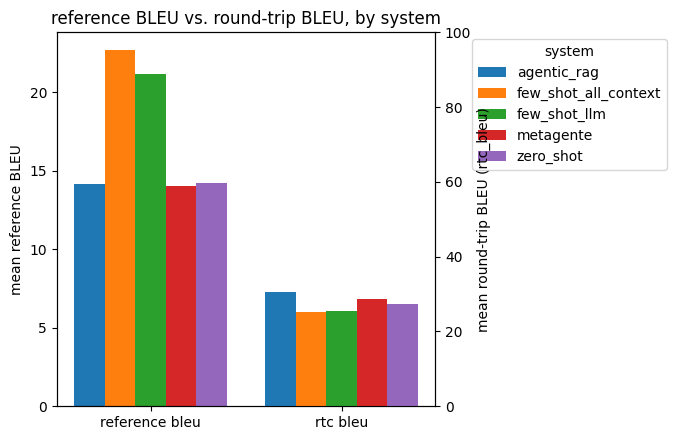

In [16]:
import matplotlib.pyplot as plt

SYSTEMS_TO_PLOT = ["few_shot_llm", "metagente", "few_shot_all_context", "zero_shot", "agentic_rag"]

plot_summary = system_summary.loc[[s for s in system_summary.index if s in SYSTEMS_TO_PLOT]]
systems = list(plot_summary.index)
colors = plt.cm.tab10.colors

fig, ax_bleu = plt.subplots(figsize=(7, 4.5))
ax_rtc = ax_bleu.twinx()

n = len(systems)
width = 0.8 / n
group_x = {"reference bleu": 0, "rtc bleu": 1}

for i, system in enumerate(systems):
    offset = (i - (n - 1) / 2) * width
    color = colors[i % len(colors)]
    ax_bleu.bar(group_x["reference bleu"] + offset, plot_summary.loc[system, "mean_bleu"], width, color=color, label=system)
    ax_rtc.bar(group_x["rtc bleu"] + offset, plot_summary.loc[system, "mean_rtc"], width, color=color)

ax_bleu.set_xticks(list(group_x.values()))
ax_bleu.set_xticklabels(list(group_x.keys()))
ax_bleu.set_ylabel("mean reference BLEU")
ax_rtc.set_ylabel("mean round-trip BLEU (rtc_bleu)")
ax_rtc.set_ylim(0, 100)
ax_bleu.set_title("reference BLEU vs. round-trip BLEU, by system")
ax_bleu.legend(title="system", loc="upper left", bbox_to_anchor=(1.08, 1))

fig.tight_layout()
plt.show()